# 01b. Análise descritiva — aplicação (sem ouro determinístico)

Mesmos gráficos do [`01_analise_descritiva.ipynb`](01_analise_descritiva.ipynb),
sobre `censo_limpo_aplicacao` ∪ `cpf_limpo_aplicacao` (lista de ouro fora).
O 01 continua no limpo cheio (treino).


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROB_DIR = Path.cwd()
if PROB_DIR.name == 'notebooks':
    PROB_DIR = PROB_DIR.parent
if str(PROB_DIR) not in sys.path:
    sys.path.insert(0, str(PROB_DIR))

%matplotlib inline

import config
from config import (
    ANO_REFERENCIA_CENSO, DATA_REFERENCIA_IDADE,
    TABELA_CENSO_LIMPA_APLICACAO, TABELA_CPF_LIMPA_APLICACAO,
    materialize_splink_input,
    get_connection, print_paths, require_tables,
)

# Descreve o que o 02b/03 vão ver: limpo sem a lista de ouro, via splink_input.
TABLE = 'splink_input'
ORIGEM_COLORS = {'cpf': '#2563eb', 'censo': '#16a34a'}


def _is_filled(col: str) -> str:
    return f"({col} IS NOT NULL AND TRIM(CAST({col} AS VARCHAR)) <> '')"


def plot_origem_counts(df, *, title='Registros por origem'):
    fig, ax = plt.subplots(figsize=(6, 4))
    colors = [ORIGEM_COLORS.get(o, '#64748b') for o in df['origem']]
    ax.bar(df['origem'], df['n'], color=colors)
    ax.set_title(title)
    ax.set_ylabel('Quantidade')
    for i, v in enumerate(df['n']):
        ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.show()


def plot_missingness_bars(df, *, title='Preenchimento por coluna (%)'):
    if df.empty:
        return
    pivot = df.pivot(index='coluna', columns='origem', values='pct_preenchido').fillna(0)
    fig, ax = plt.subplots(figsize=(10, max(4, len(pivot) * 0.35)))
    pivot.plot(kind='barh', ax=ax, color=[ORIGEM_COLORS.get(c, '#64748b') for c in pivot.columns])
    ax.set_xlabel('% preenchido')
    ax.set_title(title)
    ax.legend(title='Origem')
    ax.set_xlim(0, 100)
    plt.tight_layout()
    plt.show()


def plot_top_bars(df, *, title, value_col='valor', split_by_origem=True):
    if df.empty:
        return
    origens = df['origem'].unique() if split_by_origem else [None]
    ncols = len(origens) if split_by_origem else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 6), squeeze=False)
    for idx, orig in enumerate(origens if split_by_origem else [None]):
        ax = axes[0, idx]
        sub = df[df['origem'] == orig].head(20) if orig else df.head(20)
        sub = sub.sort_values('n')
        color = ORIGEM_COLORS.get(orig, '#64748b') if orig else '#64748b'
        ax.barh(sub[value_col], sub['n'], color=color)
        ax.set_title(f'{title}' + (f' — {orig}' if orig else ''))
        ax.set_xlabel('Quantidade')
    plt.tight_layout()
    plt.show()


def plot_sexo_distribution(df):
    if df.empty:
        return
    pivot = df.pivot(index='sexo_cat', columns='origem', values='n').fillna(0)
    fig, ax = plt.subplots(figsize=(7, 4))
    pivot.plot(kind='bar', ax=ax, color=[ORIGEM_COLORS.get(c, '#64748b') for c in pivot.columns])
    ax.set_title('Distribuição de sexo')
    ax.set_ylabel('Quantidade')
    ax.set_xlabel('Sexo')
    ax.legend(title='Origem')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


def plot_dob_year_hist(df):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    for orig in df['origem'].unique():
        sub = df[df['origem'] == orig]
        ax.hist(
            sub['ano'], bins=30, alpha=0.55, label=orig,
            weights=sub['n'], color=ORIGEM_COLORS.get(orig, '#64748b'),
        )
    ax.set_title('Distribuição do ano de nascimento')
    ax.set_xlabel('Ano')
    ax.set_ylabel('Quantidade')
    ax.legend(title='Origem')
    plt.tight_layout()
    plt.show()


def plot_idade_hist(df, *, data_ref=DATA_REFERENCIA_IDADE):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(10, 4))
    for orig in df['origem'].unique():
        sub = df[df['origem'] == orig]
        ax.hist(
            sub['idade'], bins=range(0, 101, 5), alpha=0.55, label=orig,
            weights=sub['n'], color=ORIGEM_COLORS.get(orig, '#64748b'),
        )
    ax.set_title(f'Distribuição de idade (referência {data_ref})')
    ax.set_xlabel('Idade (anos)')
    ax.set_ylabel('Quantidade')
    ax.legend(title='Origem')
    plt.tight_layout()
    plt.show()


def plot_cep_prefix(df, *, title='Top prefixos CEP (5 dígitos)'):
    plot_top_bars(df, title=title, value_col='cep5')


def plot_uf_distribution(df):
    if df.empty:
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    for orig in df['origem'].unique():
        sub = df[df['origem'] == orig].sort_values('n', ascending=False).head(10)
        ax.bar(
            [f'{orig}:{u}' for u in sub['uf']], sub['n'],
            color=ORIGEM_COLORS.get(orig, '#64748b'), alpha=0.85, label=orig,
        )
    ax.set_title('UF — top 10 por origem')
    ax.set_ylabel('Quantidade')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


print_paths()
print('FILTRO_UF:', config.FILTRO_UF, '| FILTRO_MUNICIPIO:', config.FILTRO_MUNICIPIO)
con = get_connection()
require_tables(
    con,
    [TABELA_CENSO_LIMPA_APLICACAO, TABELA_CPF_LIMPA_APLICACAO],
    notebook_origem='00b',
)
materialize_splink_input(
    con,
    censo_table=TABELA_CENSO_LIMPA_APLICACAO,
    cpf_table=TABELA_CPF_LIMPA_APLICACAO,
)


OUTPUT_DIR_BASE: /home/ibge.gov.br/ramon.goncalves/data/probabilistico_output
OUTPUT_DIR: /home/ibge.gov.br/ramon.goncalves/data/probabilistico_output/uf_21
recorte: uf_21
CPF_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/cpf/cpf.parquet
CENSO_PESSOAS_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/censo/censo_pessoas_2022_20260505.parquet
CENSO_PES_NOME_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/censo/censo_pes_nome.parquet
CPF_CPF_NOME_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/cpf/cpf_cpf_nome.parquet
CENSO_ESPECIE_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/censo/censo_especie.parquet
CENSO_LOGR_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/singed/bases/bronze/censo/censo_logr.parquet
COHORT_DEDUP_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/capefe/dados/CohortDados/cohort_dedup.parquet
LISTA_OURO_ARQUIVO: /home/ibge.gov.br/ramon.goncalves/capefe/scripts_luis/Pareamento Determinístico/V4 20260827/

('censo_limpo_aplicacao', 'cpf_limpo_aplicacao')

## 1. Visão geral


,origem,n
0,censo,6079030
1,cpf,7931465


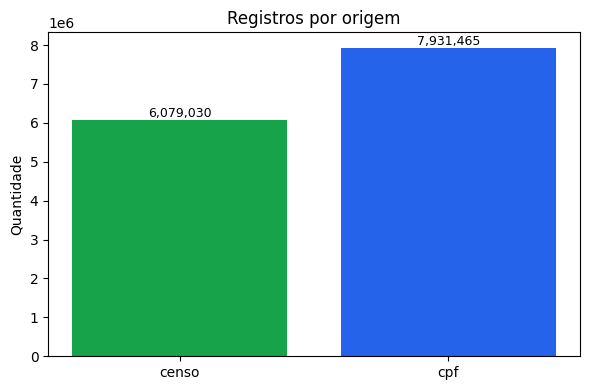

In [2]:
df_origem = con.execute(f"""
SELECT origem, COUNT(*) AS n
FROM {TABLE}
GROUP BY origem
ORDER BY origem
""").df()
display(df_origem)
plot_origem_counts(df_origem)

### Município (`cod_municipio`)

Coerência com `FILTRO_MUNICIPIO` (IBGE 7 dígitos).

In [3]:
cols = set(con.execute(f'SELECT * FROM {TABLE} LIMIT 0').df().columns)
if 'cod_municipio' in cols:
    display(con.execute(f'''
    SELECT origem, cod_municipio, COUNT(*) AS n
    FROM {TABLE}
    WHERE cod_municipio IS NOT NULL AND TRIM(CAST(cod_municipio AS VARCHAR)) <> ''
    GROUP BY origem, cod_municipio
    ORDER BY n DESC
    LIMIT 10
    ''').df())
else:
    print('cod_municipio ausente — rode NB00 com REBUILD=True')

,origem,cod_municipio,n
0,cpf,2111300,1405510
1,censo,2111300,910177
2,cpf,2105302,383737
3,censo,2105302,246113
4,censo,2111201,217564
5,cpf,2111201,212479
6,cpf,2103000,200413
7,cpf,2112209,195875
8,censo,2112209,149867
9,cpf,2103307,146432


## 2. Missingness


origem,censo,cpf
coluna,,
cep,11.1,0.0
cpf_norm,100.0,0.0
data_nascimento,16.1,3.2
idade,83.9,3.2
nome_completo,0.0,0.0
nome_completo_phon,0.0,0.0
nome_mae,63.9,3.3
nome_mae_phon,63.9,3.3
nome_meio,12.3,4.0


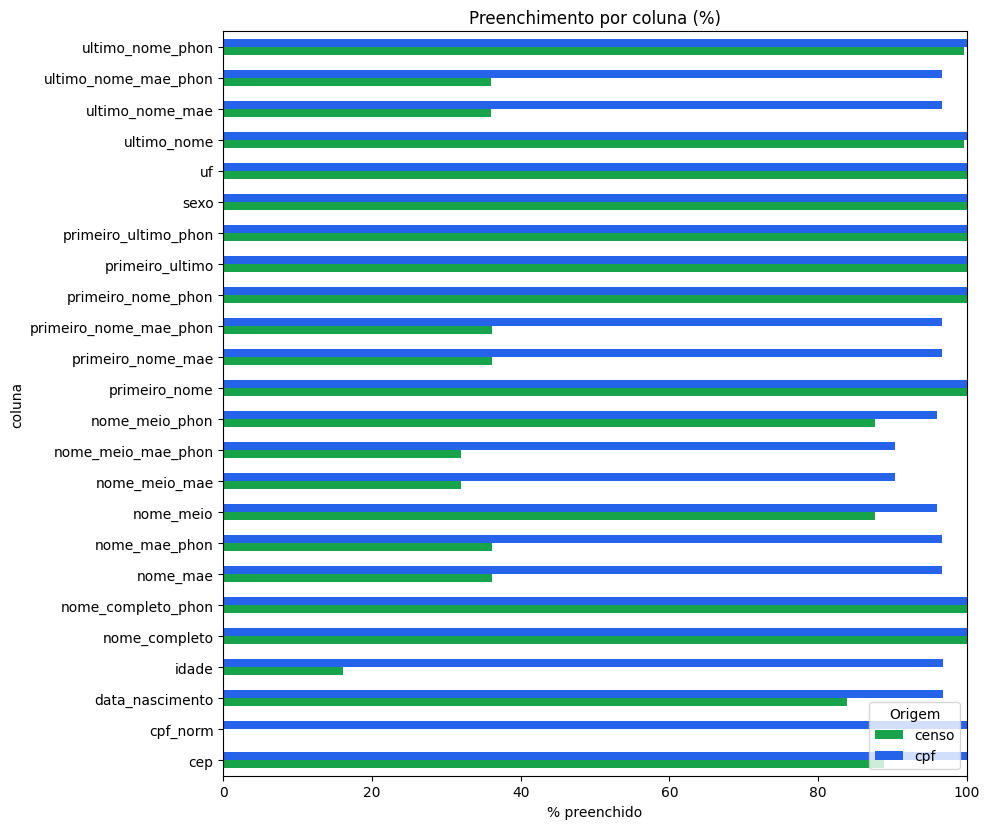

In [4]:
EDA_COLS = [
    'nome_completo', 'primeiro_nome', 'nome_meio', 'ultimo_nome', 'primeiro_ultimo',
    'nome_mae', 'primeiro_nome_mae', 'nome_meio_mae', 'ultimo_nome_mae',
    'sexo', 'data_nascimento', 'idade', 'cep', 'uf', 'cpf_norm',
    'nome_completo_phon', 'primeiro_nome_phon', 'nome_meio_phon', 'ultimo_nome_phon',
    'primeiro_ultimo_phon',
    'nome_mae_phon', 'primeiro_nome_mae_phon', 'nome_meio_mae_phon', 'ultimo_nome_mae_phon',
]

available = set(con.execute(f'SELECT * FROM {TABLE} LIMIT 0').df().columns)
cols = [c for c in EDA_COLS if c in available]

rows = []
for col in cols:
    rows.append(con.execute(f"""
    SELECT
        '{col}' AS coluna,
        origem,
        COUNT(*) AS n,
        SUM(CASE WHEN {_is_filled(col)} THEN 1 ELSE 0 END) AS preenchido
    FROM {TABLE}
    GROUP BY origem
    """).df())

df_missing = pd.concat(rows, ignore_index=True)
df_missing['pct_preenchido'] = (df_missing['preenchido'] / df_missing['n'] * 100).round(1)
df_missing['pct_missing'] = (100 - df_missing['pct_preenchido']).round(1)

display(df_missing.pivot(index='coluna', columns='origem', values='pct_missing').round(1))
plot_missingness_bars(df_missing)

## 3. Nomes


,origem,valor,n
0,cpf,MARIA,710289
1,censo,MARIA,516602
2,cpf,JOSE,318910
3,censo,JOSE,201868
4,cpf,ANTONIO,201275
5,cpf,FRANCISCO,171954
6,cpf,JOAO,169365
7,cpf,ANA,152929
8,cpf,RAIMUNDO,140514
9,censo,ANA,135435


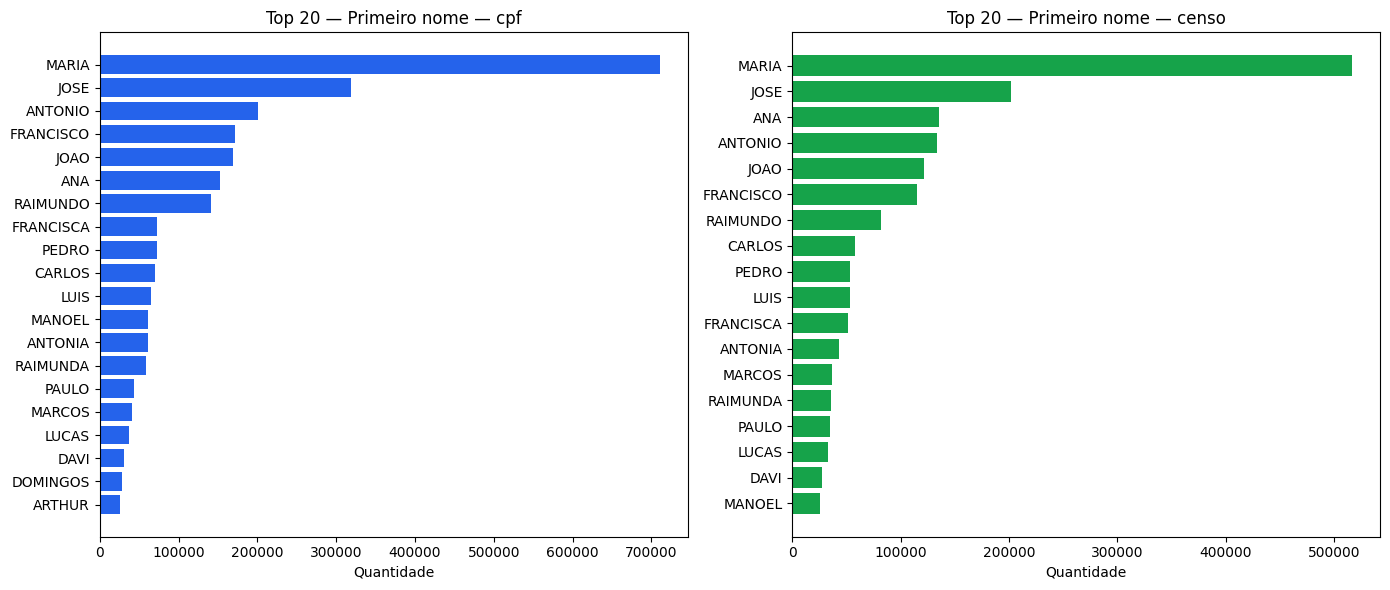

,origem,valor,n
0,cpf,SILVA,1181867
1,censo,SILVA,865803
2,cpf,SANTOS,619111
3,censo,SANTOS,456537
4,cpf,SOUSA,451787
5,censo,SOUSA,371681
6,cpf,COSTA,262098
7,cpf,OLIVEIRA,241071
8,cpf,LIMA,205958
9,censo,COSTA,195683


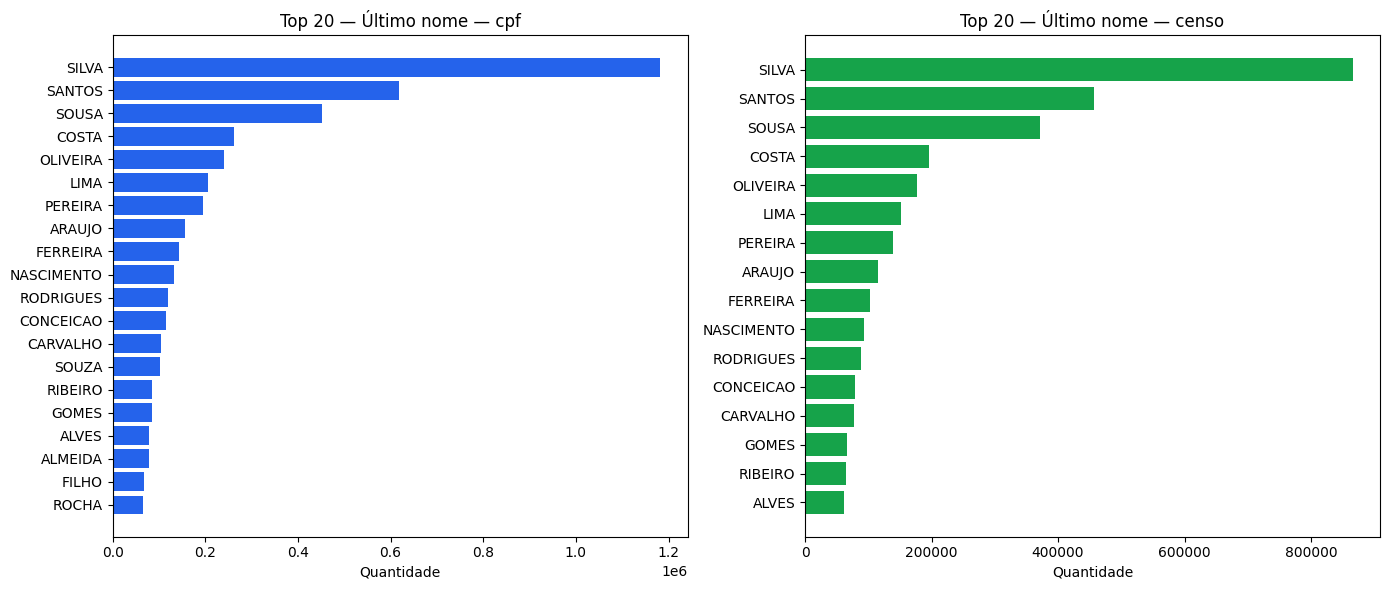

,origem,n,com_meio,pct_meio
0,cpf,7931465,7616497.0,96.0
1,censo,6079030,5333960.0,87.7


In [5]:
for col, titulo in [('primeiro_nome', 'Primeiro nome'), ('ultimo_nome', 'Último nome')]:
    df_top = con.execute(f"""
    SELECT origem, CAST({col} AS VARCHAR) AS valor, COUNT(*) AS n
    FROM {TABLE}
    WHERE {_is_filled(col)}
    GROUP BY origem, valor
    ORDER BY n DESC
    LIMIT 40
    """).df()
    display(df_top.head(10))
    plot_top_bars(df_top, title=f'Top 20 — {titulo}')

display(con.execute(f"""
SELECT
    origem,
    COUNT(*) AS n,
    SUM(CASE WHEN {_is_filled('nome_meio')} THEN 1 ELSE 0 END) AS com_meio,
    ROUND(100.0 * SUM(CASE WHEN {_is_filled('nome_meio')} THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_meio
FROM {TABLE}
GROUP BY origem
""").df())

## 4. Sexo


,origem,sexo_cat,n
0,censo,F,3028397
1,censo,M,3050633
2,cpf,(vazio),1119
3,cpf,F,3828022
4,cpf,M,4102324


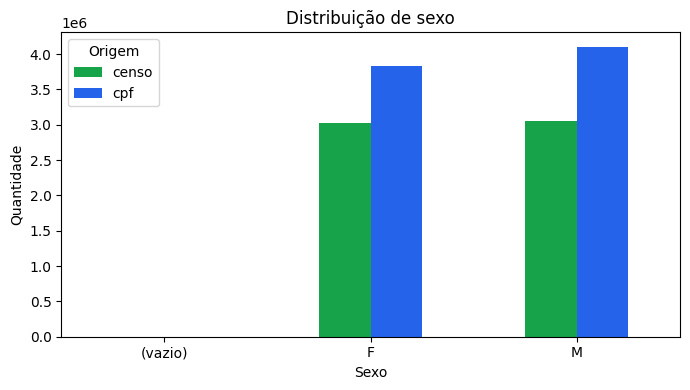

In [6]:
df_sexo = con.execute(f"""
SELECT
    origem,
    CASE
        WHEN NOT ({_is_filled('sexo')}) THEN '(vazio)'
        WHEN UPPER(TRIM(CAST(sexo AS VARCHAR))) IN ('M', 'MASC', 'MASCULINO', '1') THEN 'M'
        WHEN UPPER(TRIM(CAST(sexo AS VARCHAR))) IN ('F', 'FEM', 'FEMININO', '2') THEN 'F'
        ELSE 'outro'
    END AS sexo_cat,
    COUNT(*) AS n
FROM {TABLE}
GROUP BY origem, sexo_cat
ORDER BY origem, sexo_cat
""").df()
display(df_sexo)
plot_sexo_distribution(df_sexo)

## 5. Data de nascimento


,origem,com_ano_valido
0,censo,5099404
1,cpf,7680834


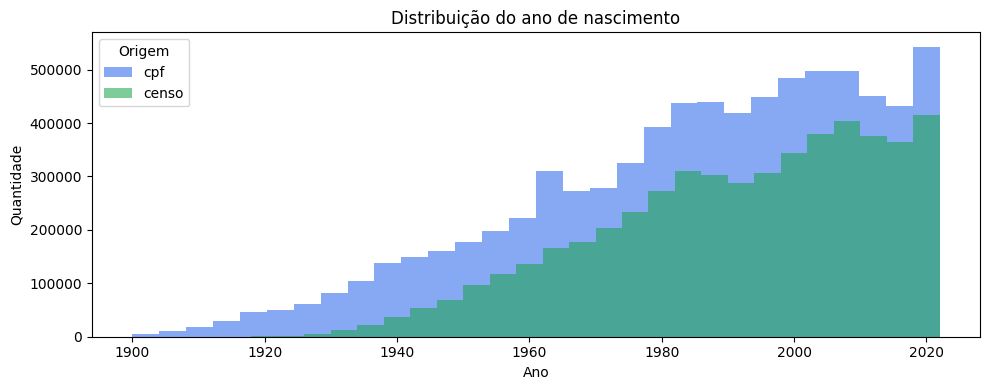

In [7]:
df_dob = con.execute(f"""
SELECT
    origem,
    TRY_CAST(substr(CAST(data_nascimento AS VARCHAR), 1, 4) AS INTEGER) AS ano,
    COUNT(*) AS n
FROM {TABLE}
WHERE {_is_filled('data_nascimento')}
  AND TRY_CAST(substr(CAST(data_nascimento AS VARCHAR), 1, 4) AS INTEGER) BETWEEN 1900 AND 2025
GROUP BY origem, ano
ORDER BY ano
""").df()
display(df_dob.groupby('origem')['n'].sum().reset_index(name='com_ano_valido'))
plot_dob_year_hist(df_dob)

## 5b. Idade (referência 2022-08-01)

Censo: `PECP0401` só quando a data validada é nula (00b zera idade se há DOB).
CPF: anos completos em `DATA_REFERENCIA_IDADE` (`2022-08-01`).

,origem,n,com_idade,pct_idade,idade_media
0,cpf,7931465,7680834.0,96.8,36.9
1,censo,6079030,979621.0,16.1,34.4


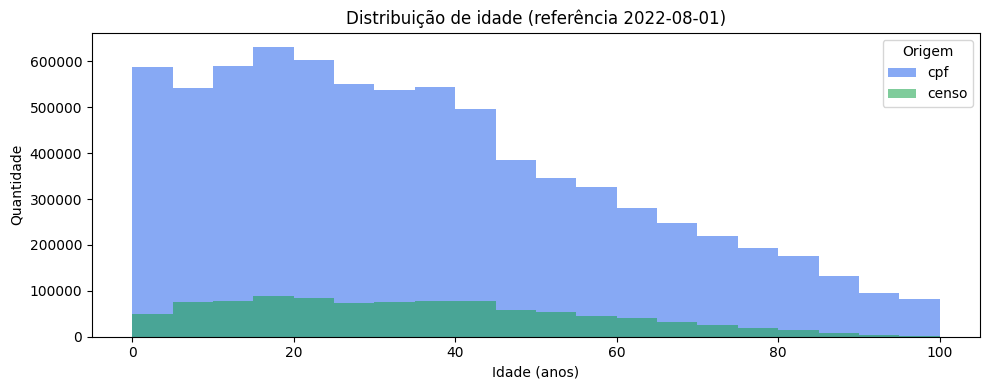

In [8]:
cols = set(con.execute(f'SELECT * FROM {TABLE} LIMIT 0').df().columns)
if 'idade' not in cols:
    print('Coluna idade ausente — rode NB00 com REBUILD=True.')
else:
    df_idade = con.execute(f"""
    SELECT origem, idade, COUNT(*) AS n
    FROM {TABLE}
    WHERE idade IS NOT NULL AND idade BETWEEN 0 AND 120
    GROUP BY origem, idade
    ORDER BY idade
    """).df()
    display(con.execute(f"""
    SELECT origem,
        COUNT(*) AS n,
        SUM(CASE WHEN idade IS NOT NULL THEN 1 ELSE 0 END) AS com_idade,
        ROUND(100.0 * SUM(CASE WHEN idade IS NOT NULL THEN 1 ELSE 0 END) / COUNT(*), 1) AS pct_idade,
        ROUND(AVG(idade), 1) AS idade_media
    FROM {TABLE}
    GROUP BY origem
    """).df())
    plot_idade_hist(df_idade)

## 6. CEP


,origem,cep5,n
0,cpf,65000,291300
1,censo,65110,217629
2,cpf,65110,178060
3,cpf,65900,159855
4,cpf,65400,146386
5,cpf,65930,140680
6,cpf,65700,127962
7,cpf,65130,124742
8,cpf,65800,121162
9,cpf,65600,119332


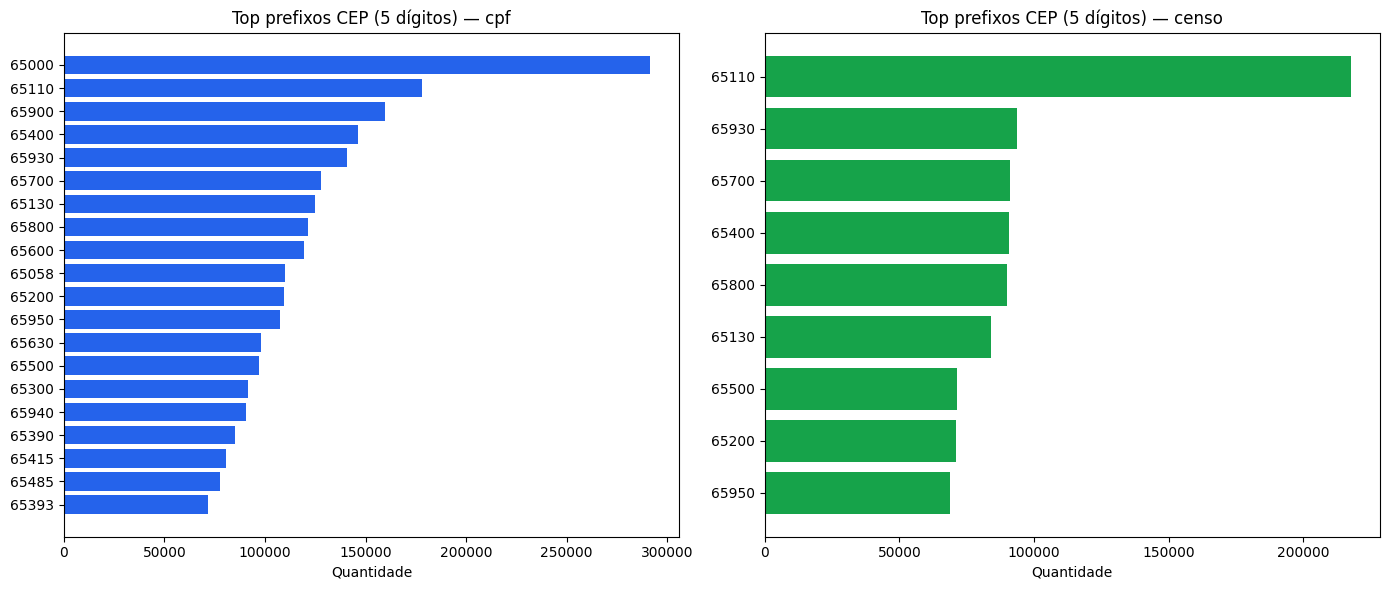

In [9]:
df_cep = con.execute(f"""
SELECT origem,
       substr(lpad(regexp_replace(CAST(cep AS VARCHAR), '[^0-9]', '', 'g'), 8, '0'), 1, 5) AS cep5,
       COUNT(*) AS n
FROM {TABLE}
WHERE {_is_filled('cep')}
GROUP BY origem, cep5
ORDER BY n DESC
LIMIT 30
""").df()
display(df_cep.head(20))
plot_cep_prefix(df_cep)

## 7. UF


,origem,uf,n
0,cpf,21,7931465
1,censo,21,6079030


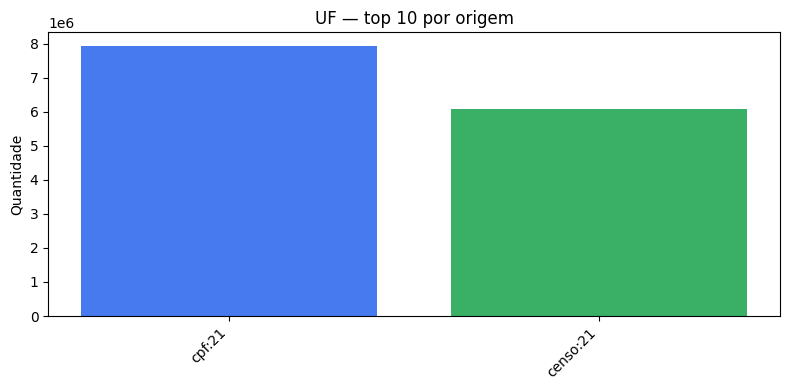

In [10]:
df_uf = con.execute(f"""
SELECT origem, CAST(uf AS VARCHAR) AS uf, COUNT(*) AS n
FROM {TABLE}
WHERE {_is_filled('uf')}
GROUP BY origem, uf
ORDER BY n DESC
""").df()
display(df_uf.head(15))
plot_uf_distribution(df_uf)

## 8. Nome da mãe


,coluna,origem,n,preenchido,pct_preenchido,pct_missing
0,nome_mae,cpf,7931465,7667336.0,96.7,3.3
1,nome_mae,censo,6079030,2194641.0,36.1,63.9


--- censo ---


,origem,valor,n
0,censo,MARIA CONCEICAO,1415
1,censo,MARIA SILVA,991
2,censo,MARIA CONCEICAO SILVA,841
3,censo,MARIA SANTOS,793
4,censo,FRANCISCA SILVA,692
5,censo,MARIA JESUS,664
6,censo,MARIA JESUS SILVA,605
7,censo,MARIA JOSE SILVA,591
8,censo,MARIA FRANCISCA SILVA,512
9,censo,MARIA CONCEICAO SANTOS,511


--- cpf ---


,origem,valor,n
15,cpf,MARIA PEREIRA SILVA,6774
16,cpf,MARIA CONCEICAO SILVA,6460
17,cpf,MARIA CONCEICAO,6077
18,cpf,MARIA JOSE SILVA,4898
19,cpf,FRANCISCA MARIA CONCEICAO,3660
20,cpf,MARIA ALVES SILVA,3659
21,cpf,RAIMUNDA MARIA CONCEICAO,3313
22,cpf,RAIMUNDA PEREIRA SILVA,3277
23,cpf,MARIA JESUS SILVA,3237
24,cpf,MARIA RODRIGUES SILVA,3221


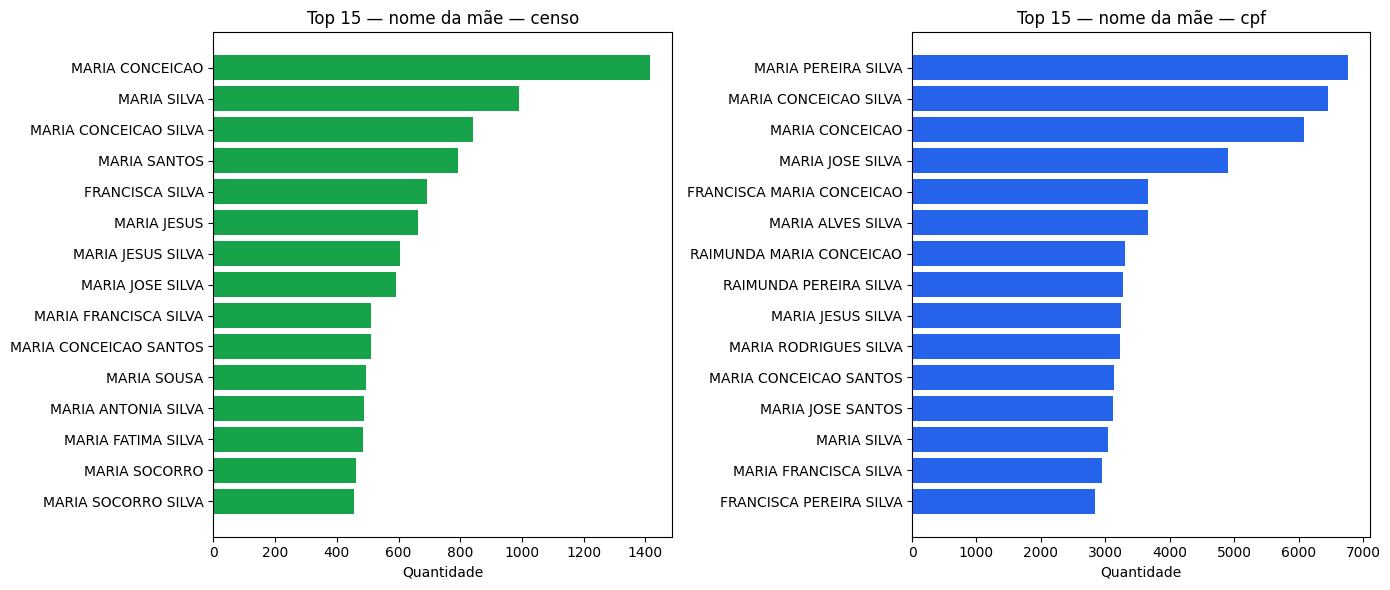

In [11]:
df_mae_miss = con.execute(f"""
SELECT
    'nome_mae' AS coluna,
    origem,
    COUNT(*) AS n,
    SUM(CASE WHEN {_is_filled('nome_mae')} THEN 1 ELSE 0 END) AS preenchido
FROM {TABLE}
GROUP BY origem
""").df()
df_mae_miss['pct_preenchido'] = (df_mae_miss['preenchido'] / df_mae_miss['n'] * 100).round(1)
df_mae_miss['pct_missing'] = (100 - df_mae_miss['pct_preenchido']).round(1)
display(df_mae_miss)

# Top 15 por origem (CPF direto vs Censo inferido)
df_mae_top = con.execute(f"""
WITH agg AS (
    SELECT origem, CAST(nome_mae AS VARCHAR) AS valor, COUNT(*) AS n
    FROM {TABLE}
    WHERE {_is_filled('nome_mae')}
    GROUP BY origem, valor
),
ranked AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY origem ORDER BY n DESC) AS rn
    FROM agg
)
SELECT origem, valor, n
FROM ranked
WHERE rn <= 15
ORDER BY origem, n DESC
""").df()
for orig in df_mae_top['origem'].unique():
    print(f'--- {orig} ---')
    display(df_mae_top[df_mae_top['origem'] == orig])
plot_top_bars(df_mae_top, title='Top 15 — nome da mãe')

## 9. Resumo

Revise acima:
- **Missingness** — colunas críticas para linkage (nome, DOB, CEP, nome_mae)
- **Nomes** — concentração nos top tokens (blocking)
- **CEP/UF** — coerência com `FILTRO_UF`


In [12]:
con.close()